# Segment Exploration

Quick exploratory notebook for exported Halfmile segments.

This notebook loads the manifest in `data/interim/Halfmile_segments`, summarizes segment coverage, and plots one example panel with manual picks.

In [1]:
from pathlib import Path
import sys

These imports are the notebook equivalent of opening the toolbox. We only pulled in filesystem and path helpers here, which keeps the early setup simple. Nothing project-specific has happened yet, but without this small step the notebook would be much harder to run reliably from different working directories.

In [2]:
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "seismic_first_break_picker").exists():
    repo_root = repo_root.parent
if not (repo_root / "seismic_first_break_picker").exists():
    raise RuntimeError("Could not locate the repository root. Start Jupyter from anywhere inside this repo.")
for path in (repo_root, repo_root / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

This cell makes the notebook location-agnostic. It walks up the directory tree until it finds the package root, then adds both the repository and the notebooks folder to Python's import path. The practical result is that every later import works the same way whether the kernel was started from the repo root, the notebooks folder, or somewhere deeper in the project.

In [3]:
from IPython.display import display
import matplotlib.pyplot as plt, numpy as np, pandas as pd

from _notebook_setup import INTERIM_DIR, require_path
from seismic_first_break_picker.data import discover_segment_records, load_segment

%matplotlib inline
plt.style.use("default")

Now the notebook is actually ready to do useful work. We bring in the plotting stack, dataframe tools, and the project helpers for reading segment manifests and `.npz` segment files. By the end of this cell, the rest of the notebook can focus on the data itself instead of setup friction.

## Notebook Setup

The cells above make the repository importable from Jupyter, then load the plotting and package utilities used throughout the notebook. The next cell points the notebook at the exported Halfmile segment artifacts that already exist in this workspace.

In [4]:
segments_dir = require_path(INTERIM_DIR / "Halfmile_segments")
manifest_path = require_path(segments_dir / "Halfmile_segments_manifest.json")

Here we point the notebook at the exact exported Halfmile artifacts we want to inspect. The `require_path` calls are doing a quiet but important job: they fail fast if the expected files are missing, so we do not spend time debugging downstream cells for the wrong reason. In practice, this cell confirms that the notebook is tied to a real export, not just a hard-coded guess.

In [5]:
records_df = pd.DataFrame(discover_segment_records(segments_dir, manifest_path))
records_df["file"] = records_df["file"].map(Path)

This is where the export becomes something we can analyze quickly. Converting the manifest into a dataframe gives us a compact index of every segment, including shot ids, trace counts, and file locations. That table is the backbone for the summary statistics and for picking representative examples later on.

## Manifest Table

This step loads the segment manifest into a dataframe. That table is the basis for all quick checks below: total segment count, shot coverage, trace lengths, and choosing a representative panel to inspect.

In [6]:
summary = pd.DataFrame(
    {
        "metric": [
            "segment_count",
            "shot_count",
            "mean_trace_count",
            "mean_valid_label_count",
            "min_trace_count",
            "max_trace_count",
        ],
        "value": [
            len(records_df),
            records_df["shot_id"].nunique(),
            round(records_df["trace_count"].mean(), 2),
            round(records_df["valid_label_count"].mean(), 2),
            int(records_df["trace_count"].min()),
            int(records_df["trace_count"].max()),
        ],
    }
)

display(summary)
display(records_df[["trace_count", "valid_label_count"]].describe().round(2))
records_df.head()

,metric,value
0,segment_count,5391.00
1,shot_count,689.00
2,mean_trace_count,149.51
3,mean_valid_label_count,135.32
4,min_trace_count,97.00
5,max_trace_count,201.00


,trace_count,valid_label_count
count,5391.00,5391.00
mean,149.51,135.32
std,44.98,40.29
min,97.00,70.00
25%,101.00,97.00
50%,141.00,127.00
75%,199.00,178.00
max,201.00,201.00


,segment_id,file,asset_name,shot_id,segment_num,trace_count,sample_count,valid_label_count,split_basis
0,Halfmile_shot20021449_seg000,data\interim\Halfmile_segments\Halfmile_shot20...,Halfmile,20021449,0,97,751,94,REC_PEG
1,Halfmile_shot20021449_seg005,data\interim\Halfmile_segments\Halfmile_shot20...,Halfmile,20021449,5,101,751,97,REC_PEG
2,Halfmile_shot20021449_seg012,data\interim\Halfmile_segments\Halfmile_shot20...,Halfmile,20021449,12,101,751,99,REC_PEG
3,Halfmile_shot20021449_seg018,data\interim\Halfmile_segments\Halfmile_shot20...,Halfmile,20021449,18,101,751,94,REC_PEG
4,Halfmile_shot20021449_seg024,data\interim\Halfmile_segments\Halfmile_shot20...,Halfmile,20021449,24,101,751,98,REC_PEG


This cell turns the manifest into a first-pass health check on the export. We can immediately see how many usable segments survived preprocessing, how many shots they cover, and how wide the spread is in trace count and valid labels. If these numbers looked strange, this would be the first place to catch it.

## Pick One Segment

After confirming the export statistics, the next cell selects one concrete segment file. It prefers a known presentation example when available and otherwise falls back to the first manifest entry.

In [7]:
preferred_segment_path = segments_dir / "Halfmile_shot20241112_seg003.npz"
segment_path = preferred_segment_path if preferred_segment_path.exists() else Path(records_df.sort_values(["shot_id", "segment_num"]).iloc[0]["file"])
segment = load_segment(segment_path)

print(f"Segment: {segment['segment_id']}")
print(f"Shape: {segment['panel'].shape[0]} samples x {segment['panel'].shape[1]} traces")
print(f"Valid labels: {int(segment['valid'].sum())} / {segment['panel'].shape[1]}")
print(f"Sample interval: {segment['sample_ms']:.2f} ms")

Segment: Halfmile_shot20241112_seg003
Shape: 751 samples x 201 traces
Valid labels: 190 / 201
Sample interval: 2.00 ms


At this point we leave the aggregate view and pick one concrete panel to inspect. The selection logic prefers a segment already used elsewhere in the project so the notebook stays aligned with the report and presentation material. The printed metadata gives a quick reality check that the file looks structurally sane before we start plotting it.

## Visual Pick Overlay

This plot is the first qualitative check: it renders the 2D seismic panel and overlays the manual first-break picks. The purpose is to verify that the stored panel orientation and label indices line up as expected.

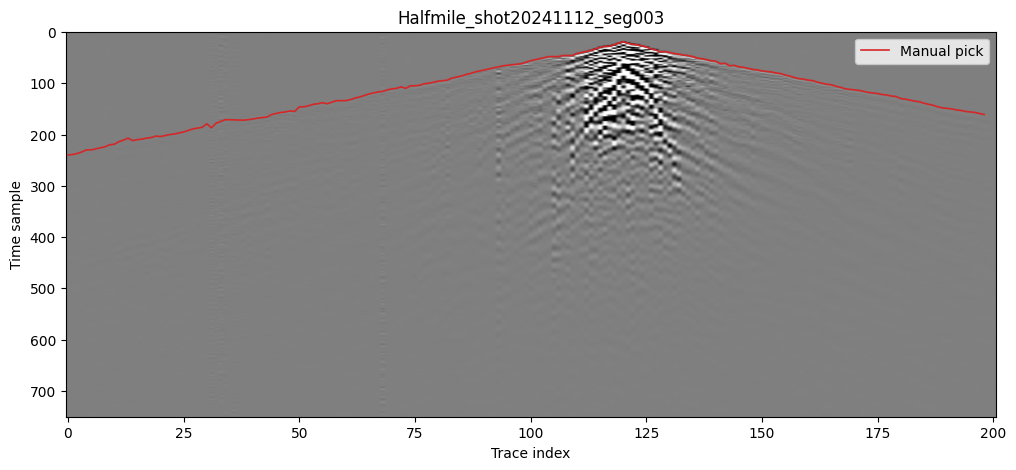

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(segment["panel"], cmap="gray", aspect="auto", origin="upper")
valid_trace_ids = np.flatnonzero(segment["valid"])
ax.plot(valid_trace_ids, segment["fb_idx"][segment["valid"]], color="tab:red", linewidth=1.2, label="Manual pick")
ax.set_title(segment["segment_id"])
ax.set_xlabel("Trace index")
ax.set_ylabel("Time sample")
ax.legend()
plt.show()

This figure answers a very practical question: do the panel and the stored manual picks line up in the way we expect? A good overlay here means the export preserved both trace ordering and label indexing correctly. It is the kind of sanity check that saves a lot of wasted effort before any modeling or evaluation work.

## Geometry Sanity Check

The final view breaks the same segment into simple diagnostics. Receiver ordering, receiver coordinates, and valid-label flags help explain why this panel was segmented the way it was and whether the geometry looks coherent.

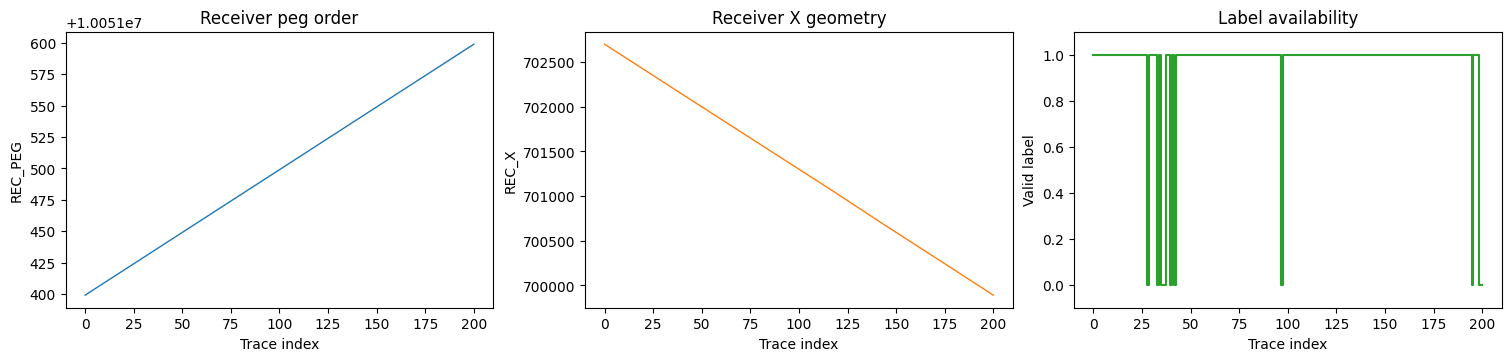

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), constrained_layout=True)

if segment["rec_peg"] is not None:
    axes[0].plot(segment["rec_peg"], linewidth=1.0)
    axes[0].set_title("Receiver peg order")
    axes[0].set_xlabel("Trace index")
    axes[0].set_ylabel("REC_PEG")
else:
    axes[0].text(0.5, 0.5, "REC_PEG not stored", ha="center", va="center")
    axes[0].set_axis_off()

if segment["rec_x"] is not None:
    axes[1].plot(segment["rec_x"], linewidth=1.0, color="tab:orange")
    axes[1].set_title("Receiver X geometry")
    axes[1].set_xlabel("Trace index")
    axes[1].set_ylabel("REC_X")
else:
    axes[1].text(0.5, 0.5, "REC_X not stored", ha="center", va="center")
    axes[1].set_axis_off()

axes[2].plot(segment["valid"].astype(int), drawstyle="steps-mid", color="tab:green")
axes[2].set_title("Label availability")
axes[2].set_xlabel("Trace index")
axes[2].set_ylabel("Valid label")
axes[2].set_ylim(-0.1, 1.1)

plt.show()

The last cell explains the panel from the geometry side rather than just the image side. Looking at receiver order, receiver coordinates, and label availability helps us understand why segmentation happened the way it did and whether the panel is internally coherent. That context matters because many first-break mistakes come from geometry issues long before they come from the picker itself.